# EDA 01 — 데이터 개요

저장소가 공개되어 있으므로 이 노트북의 출력에는 **집계 수치만** 둔다.
report 원문, StudyInstanceUID 같은 개별 식별자는 출력하지 않는다.

실행: `uv sync --group eda` 후 노트북 실행 (CPU만 사용). 데이터 경로는 `src/paths.py` 규칙을 따른다.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.constants import ID_COL, LABELS
from src.folds import make_folds
from src.paths import data_dir

DATA = data_dir()
train = pd.read_csv(DATA / "train.csv")
series = pd.read_csv(DATA / "train_series.csv")
test = pd.read_csv(DATA / "test.csv")
test_series = pd.read_csv(DATA / "test_series.csv")

# 차트 스타일: 단일 시리즈, 얇은 막대, 옅은 격자. 차트 글자는 영어(기본 글꼴에 한글이 없음)
BLUE, INK, INK2, SURFACE = "#2a78d6", "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": INK2,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": "#e5e4e0", "grid.linewidth": 0.8, "axes.axisbelow": True,
})

## 1. 규모와 라벨 유무

In [2]:
n_present = train[list(LABELS)].notna().sum(axis=1)
pd.DataFrame({
    "항목": ["train study", "라벨 12개 모두 있음", "라벨 전부 없음(report만)", "라벨 일부만 있음",
             "train 시리즈", "test study (공개본)", "test 시리즈 (공개본)"],
    "개수": [len(train), int((n_present == 12).sum()), int((n_present == 0).sum()),
             int(((n_present > 0) & (n_present < 12)).sum()), len(series), len(test), len(test_series)],
})

,항목,개수
0,train study,4407
1,라벨 12개 모두 있음,58
2,라벨 전부 없음(report만),4349
3,라벨 일부만 있음,0
4,train 시리즈,24371
5,test study (공개본),3
6,test 시리즈 (공개본),15


**라벨이 달린 study는 전체의 1.3%뿐이다.** CV는 이 58개로만 계산되므로 fold당 약 12개,
라벨별 양성 수는 한 자릿수가 된다. CV 분산이 매우 클 것이고, report에서 라벨을 뽑는
pseudo-label이 사실상 학습 데이터의 대부분을 만든다.

## 2. 라벨 양성률 (라벨 있는 study 기준)

In [3]:
labeled = train[n_present == 12]
prev = pd.DataFrame({
    "양성 수": labeled[list(LABELS)].sum().astype(int),
    "양성률": labeled[list(LABELS)].mean().round(3),
})
prev

,양성 수,양성률
ACL,24,0.414
MCL,9,0.155
Medial Meniscus,26,0.448
Lateral Meniscus,23,0.397
Medial OA,15,0.259
Lateral OA,11,0.190
PF OA,21,0.362
Effusion,35,0.603
Synovitis,27,0.466
Baker's,12,0.207


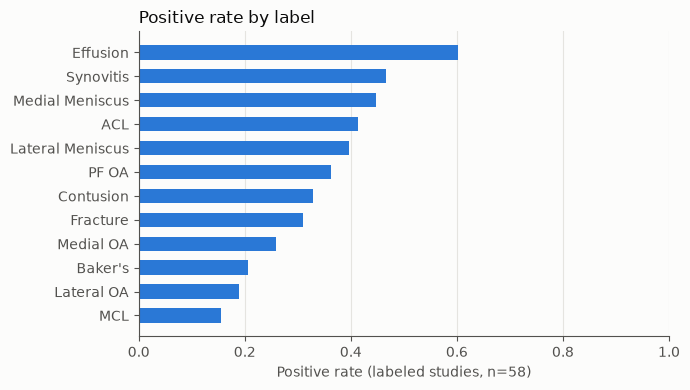

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
order = prev.sort_values("양성률").index
ax.barh(order, prev.loc[order, "양성률"], color=BLUE, height=0.6)
ax.set_xlabel(f"Positive rate (labeled studies, n={len(labeled)})")
ax.set_xlim(0, 1)
ax.grid(axis="y", visible=False)
ax.set_title("Positive rate by label", loc="left", color=INK)
plt.tight_layout()

## 3. 시리즈 구성

In [5]:
combo = series.groupby(["Anatomical_Plane", "Fluid_Sensitive", "Fat_Suppression"]).size()
combo.rename("시리즈 수").to_frame()

시리즈 수
Anatomical_Plane Fluid_Sensitive Fat_Suppression       
Axial            0               0                 1179
                 1               1                 4719
Coronal          0               0                 3985
                 1               1                 4624
Sagittal         0               0                 5197
                 1               1                 4667

In [6]:
per_study = series.groupby("StudyInstanceUID").size()
planes = series.groupby("StudyInstanceUID")["Anatomical_Plane"].agg(lambda s: "+".join(sorted(set(s))))
print("study당 시리즈 수:", per_study.describe()[["min", "25%", "50%", "75%", "max"]].to_dict())
planes.value_counts().rename("study 수").to_frame()

study당 시리즈 수: {'min': 3.0, '25%': 5.0, '50%': 5.0, '75%': 6.0, 'max': 14.0}


,study 수
Anatomical_Plane,
Axial+Coronal+Sagittal,4407


                   min   25%   50%   75%    max
Anatomical_Plane                               
Axial             12.0  28.0  32.0  38.0  200.0
Coronal           11.0  25.0  30.0  32.0   80.0
Sagittal          11.0  25.0  30.0  33.0  320.0


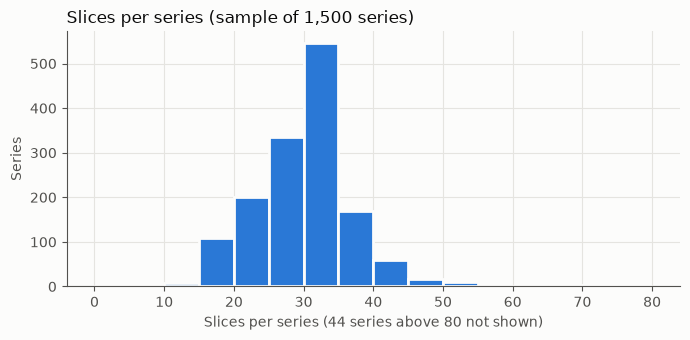

In [7]:
# 슬라이스 수: 시리즈 1500개 표본의 파일 수 (전체를 세면 디렉터리 순회가 오래 걸린다)
sample = series.sample(1500, random_state=0)
counts = [
    len(os.listdir(DATA / "train_series" / r.StudyInstanceUID / r.SeriesInstanceUID))
    for r in sample.itertuples()
]
sample = sample.assign(n_slices=counts)
print(sample.groupby("Anatomical_Plane")["n_slices"].describe()[["min", "25%", "50%", "75%", "max"]])

CAP = 80
n_over = int((sample["n_slices"] > CAP).sum())
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(sample.loc[sample["n_slices"] <= CAP, "n_slices"], bins=np.arange(0, CAP + 5, 5),
        color=BLUE, edgecolor=SURFACE, linewidth=2)
ax.set_xlabel(f"Slices per series ({n_over} series above {CAP} not shown)")
ax.set_ylabel("Series")
ax.set_title("Slices per series (sample of 1,500 series)", loc="left", color=INK)
plt.tight_layout()

## 4. Report 언어와 길이

In [8]:
from langdetect import DetectorFactory, detect

DetectorFactory.seed = 0

def _lang(text: str) -> str:
    try:
        return detect(text)
    except Exception:
        return "unknown"

lang = train["Report"].map(_lang)
length = train["Report"].str.len()
pd.DataFrame({
    "study 수": lang.value_counts(),
    "라벨 있는 study 수": lang[n_present == 12].value_counts(),
    "report 길이 중앙값": length.groupby(lang).median(),
}).fillna(0).astype(int).sort_values("study 수", ascending=False)

,study 수,라벨 있는 study 수,report 길이 중앙값
Report,,,
en,1736,28,1270
es,682,10,752
tr,546,6,692
hr,406,4,1172
el,321,3,858
de,262,2,807
bg,220,3,999
nl,153,2,918
fr,81,0,1560


## 5. test 구성 (공개본)

In [9]:
print("test.csv 컬럼:", list(test.columns), "→ report 없음" if "Report" not in test.columns else "")
test_series.groupby(["Anatomical_Plane", "Fluid_Sensitive", "Fat_Suppression"]).size().rename("시리즈 수").to_frame()

test.csv 컬럼: ['StudyInstanceUID'] → report 없음


시리즈 수
Anatomical_Plane Fluid_Sensitive Fat_Suppression       
Axial            0               0                    1
                 1               1                    3
Coronal          0               0                    1
                 1               1                    3
Sagittal         0               0                    4
                 1               1                    3

## 6. fold 분할 확인 (`folds/folds_v1.csv`와 같은 규칙)

In [10]:
folds = make_folds(train, n_splits=5, seed=42)
merged = train.merge(folds, on=ID_COL)
lab = merged[merged["labeled"]]
table = lab.groupby("fold")[list(LABELS)].sum().astype(int).T
table["합계"] = table.sum(axis=1)
print("fold별 study 수:")
print(merged.groupby(["fold", "labeled"]).size().unstack())
table

fold별 study 수:
labeled  False  True 
fold                 
0          870     12
1          870     10
2          870     12
3          870     11
4          869     13


fold,0,1,2,3,4,합계
ACL,4,6,4,4,6,24
MCL,2,1,2,2,2,9
Medial Meniscus,5,6,5,4,6,26
Lateral Meniscus,4,4,5,5,5,23
Medial OA,3,3,3,3,3,15
Lateral OA,2,3,2,2,2,11
PF OA,4,4,4,5,4,21
Effusion,5,6,10,5,9,35
Synovitis,6,6,5,5,5,27
Baker's,3,3,2,2,2,12


## 요약
- 라벨 있는 study 58개(1.3%) → CV가 매우 불안정하다. 라벨별 AUC와 fold 표준편차를 반드시 같이 본다.
- 양성 수가 한 자릿수인 라벨은 일부 fold에서 AUC가 정의되지 않을 수 있다(`macro_auc`가 NaN으로 제외).
- report만 있는 study 4349개가 학습 데이터의 대부분 → report → 라벨 추출이 다음 핵심 작업.
- test에는 report가 없다. 추론 경로는 영상만 쓴다.